# Trekk, lekkasje og den første maskinlæringsmodellen

Arbeidsverk 2, notebook 03. Bygger på notebook 01 (hva datagrunnlaget inneholder) og
notebook 02 (hva en modell skal måles mot).

Her estimeres den første maskinlæringsmodellen. Rammen er lagt: 372 prognosepunkter
fra 31 opprinnelser, MASE og intervallskår, og en modellstige å måle mot der to av
trinnene er kontrollert i Python.

Notebooken er organisert rundt en forhåndsregistrering. Avsnitt 3 skriver ned fire
påstander om hva som kommer til å skje, med begrunnelse fra tallene i notebook 01 og
fra litteraturen, **før** noen modell kjøres. Avsnitt 10 gjør opp. Én av de fire
holdt ikke, og den er den mest interessante.


## 1. Oppsett


In [1]:
import os, subprocess, sys

def git(*a, standard=None):
    try:
        return subprocess.run(["git", *a], capture_output=True, text=True,
                              check=True, cwd=REPO).stdout.strip()
    except Exception:
        return standard

REPO = "/content/bostotte-oslo" if os.path.isdir("/content/bostotte-oslo") else "."
if not os.path.isdir(os.path.join(REPO, "data")):
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/Torcode/bostotte-oslo.git",
                    "/content/bostotte-oslo"], check=True)
    REPO = "/content/bostotte-oslo"
elif REPO.startswith("/content"):
    git("fetch", "--depth", "1", "origin", "main"); git("reset", "--hard", "origin/main")

try:
    import xgboost
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "xgboost"], check=True)
    import xgboost

COMMIT, UTTREKK = git("rev-parse", "--short", "HEAD", standard="ukjent"), "2026-08-04"
print("repo    :", os.path.abspath(REPO))
print("commit  :", COMMIT)
print("uttrekk :", UTTREKK)
print("xgboost :", xgboost.__version__)


repo    : /home/claude/bostotte-oslo
commit  : 056030c
uttrekk : 2026-08-04
xgboost : 3.2.0


### Harmoni med git, og lenken bakover til notebook 02

Samme to kontroller som før: at denne kopien er bygget fra samme revisjon som `main`,
og at notebook 02 arbeidet på samme uttrekk. Den siste henter notebook 02s manifest
fra `main` og sammenlikner sjekksum og uttrekksdato.


In [2]:
# harmoni-med-git: denne cellen holdes utenfor sitt eget avtrykk
KILDEAVTRYKK = "809a88a8530248ee01d1b08116973d3d1c95574aea37ca98a2ec1aea461ebcee"
FIL_MEG = "bostotte_03_trekk_og_trebasert.ipynb"
RAATT = f"https://raw.githubusercontent.com/Torcode/bostotte-oslo/main/notebooks/{FIL_MEG}"
LOGG  = ("https://api.github.com/repos/Torcode/bostotte-oslo/commits"
         f"?path=notebooks/{FIL_MEG}&per_page=1")

import hashlib, json
import urllib.request, urllib.error

def kildeavtrykk(celler):
    ut = []
    for c in celler:
        kilde = c["source"] if isinstance(c["source"], str) else "".join(c["source"])
        if "harmoni-med-git" not in kilde:
            ut.append(kilde)
    return hashlib.sha256("\n".join(ut).encode("utf-8")).hexdigest()

def hent(url, sekunder=30):
    with urllib.request.urlopen(url, timeout=sekunder) as r:
        return json.load(r)

try:    NAAR = " (sist endret " + hent(LOGG)[0]["commit"]["committer"]["date"][:10] + ")"
except Exception: NAAR = ""

try:
    paa_main = kildeavtrykk(hent(RAATT)["cells"])
    MANIFEST_HARMONI = "i harmoni" if paa_main == KILDEAVTRYKK else "avvik mot main"
    print(f"I harmoni med main{NAAR}." if paa_main == KILDEAVTRYKK else
          f"AVVIK mot main. denne {KILDEAVTRYKK[:16]}..., main {paa_main[:16]}...{NAAR}\n"
          "  raw.githubusercontent.com mellomlagrer noen minutter.")
except urllib.error.HTTPError as e:
    MANIFEST_HARMONI = "finnes ikke paa main" if e.code == 404 else f"HTTP {e.code}"
    print("Notebooken ligger ikke paa main ennaa." if e.code == 404
          else f"Kontrollen fikk HTTP {e.code}.")
except Exception as e:
    MANIFEST_HARMONI = f"ikke sjekket ({type(e).__name__})"
    print(f"Kontrollen naadde ikke GitHub ({type(e).__name__}).")


Notebooken ligger ikke paa main ennaa.


In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import platform, importlib, time
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression

RAW = os.path.join(REPO, "data/raw/")
FIL = "husbanken_bostotte_oslo_manedlig.csv"

def sha256(sti, blokk=1 << 20):
    h = hashlib.sha256()
    with open(sti, "rb") as f:
        for b in iter(lambda: f.read(blokk), b""):
            h.update(b)
    return h.hexdigest()

SJEKKSUM = sha256(RAW + FIL)
NB02 = ("https://raw.githubusercontent.com/Torcode/bostotte-oslo/"
        "main/notebooks/bostotte_02_protokoll.ipynb")

def manifest_fra_notebook(url, noekkel):
    nb = hent(url, 40)
    for celle in reversed(nb["cells"]):
        if celle["cell_type"] == "code" and noekkel in "".join(celle["source"]):
            for u in celle.get("outputs", []):
                if u.get("output_type") == "stream":
                    return json.loads("".join(u["text"]))
    raise LookupError("fant ikke manifestet")

try:
    M02 = manifest_fra_notebook(NB02, 'MANIFEST["protokoll"]')
    LIK = M02["sjekksum"][FIL] == SJEKKSUM and M02["uttrekk"] == UTTREKK
    assert LIK, "notebook 02 arbeidet paa et annet uttrekk"
    LENKE = "samme uttrekk og samme fil"
    print(f"Notebook 02 paa main: uttrekk {M02['uttrekk']}, "
          f"{M02['protokoll']['opprinnelser']} opprinnelser, "
          f"{M02['kontroll_mot_arbeidsverk1']['avvik']} avvik mot arbeidsverk 1.")
except Exception as e:
    M02, LENKE = None, f"ikke sjekket ({type(e).__name__})"
    print(f"Naadde ikke notebook 02 paa main ({type(e).__name__}).")

SEED = 20260807
np.random.seed(SEED)
pd.set_option("display.width", 130); pd.set_option("display.max_columns", 30)

SERIE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
BLEKK, BLEKK_2, DEMPET = "#0b0b0b", "#52514e", "#898781"
RUTE, BASIS = "#e1e0d9", "#c3c2b7"
HARDT = chr(160)
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 130, "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "font.size": 8.5, "axes.titlesize": 9.5, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 8,
    "text.color": BLEKK, "axes.labelcolor": BLEKK_2,
    "xtick.color": DEMPET, "ytick.color": DEMPET,
    "xtick.labelcolor": BLEKK_2, "ytick.labelcolor": BLEKK_2,
    "axes.edgecolor": BASIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": RUTE, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False, "legend.fontsize": 7.5,
    "lines.linewidth": 1.6, "lines.solid_capstyle": "round"})

def tusen(v, _=None):
    return f"{v:,.0f}".replace(",", HARDT)

MANIFEST = {"commit": COMMIT, "uttrekk": UTTREKK, "python": platform.python_version(),
            "pakker": {}, "sjekksum": {FIL: SJEKKSUM}, "seed": SEED,
            "lenke_notebook02": LENKE}
for p in ["numpy", "pandas", "sklearn", "xgboost", "matplotlib"]:
    try:    MANIFEST["pakker"][p] = importlib.import_module(p).__version__
    except ImportError: MANIFEST["pakker"][p] = None
print("\npakker:", MANIFEST["pakker"])


Notebook 02 paa main: uttrekk 2026-08-04, 31 opprinnelser, 0 avvik mot arbeidsverk 1.

pakker: {'numpy': '2.4.4', 'pandas': '3.0.2', 'sklearn': '1.8.0', 'xgboost': '3.2.0', 'matplotlib': '3.10.9'}


## 2. Protokollen, gjentatt og kontrollert på nytt

Notebook 02 endte med at protokollfunksjonene bor i en notebook og ikke i en pakke,
og at ingenting hindrer at kopiene glir fra hverandre. Løsningen inntil pakken finnes
er ikke å love at kopien er lik, men å **måle det**: cellene under gjentar
protokollen og kjører den samme kontrollen på nytt. Treffer de ti tallene fra
arbeidsverk 1 igjen, er linjalen den samme.


In [4]:
raa = pd.read_csv(RAW + FIL)
raa["dato"] = pd.to_datetime(dict(year=raa.aar, month=raa.manedsnr, day=1))
raa = raa.sort_values("dato").reset_index(drop=True)
kant = raa.index[(raa.dato == raa.dato.max()) & (raa.ant_husstander_termin == 0)]
termin = raa.drop(index=kant).reset_index(drop=True)
est = termin[termin.dato >= "2017-01-01"].reset_index(drop=True)

M, N_EST = est.set_index("dato")["ant_husstander_termin"].astype(float), len(est)
LOG_M = np.log(M)
MIN_TRENING, H_MAKS = 72, 12
OPPRINNELSER = [est.dato.iloc[i-1] for i in range(1, N_EST+1)
                if MIN_TRENING <= i <= N_EST - H_MAKS]
NEVNER = {t0: np.abs(M.loc[:t0].values[12:] - M.loc[:t0].values[:-12]).mean()
          for t0 in OPPRINNELSER}
Z80 = 1.2815515655446004
ALFA = 0.20

def intervallskaar(sant, nedre, ovre, alfa=ALFA):
    return ((ovre - nedre) + (2/alfa)*(nedre - sant)*(sant < nedre)
            + (2/alfa)*(sant - ovre)*(sant > ovre))

def maal(R, kol):
    e = R.sant - np.exp(R[kol])
    return pd.Series({"MASE": (e.abs()/R.q).mean(),
                      "RMSE": np.sqrt((e**2).mean())})

assert (len(OPPRINNELSER), N_EST) == (31, 114)

# Kontrollen fra notebook 02, kjoert paa nytt.
kon = []
for t0 in OPPRINNELSER:
    tr = LOG_M.loc[:t0]
    sd0 = np.sqrt((np.diff(tr.values)**2).mean())
    sd1 = np.sqrt(((tr.values[12:] - tr.values[:-12])**2).mean())
    for h in range(1, H_MAKS+1):
        m_ = t0 + pd.DateOffset(months=h)
        kon.append(dict(opprinnelse=t0, h=h, dato=m_, sant=M.loc[m_], q=NEVNER[t0],
                        M0=tr.iloc[-1], sd_M0=sd0*np.sqrt(h),
                        M1=LOG_M.loc[m_ - pd.DateOffset(months=12*int(np.ceil(h/12)))],
                        sd_M1=sd1*np.sqrt(1 + (h-1)//12)))
K = pd.DataFrame(kon)

DEL1 = {"M0": [1.003, 1698, 91, 98, 7082], "M1": [1.228, 1844, 77, 97, 6125]}
kontroll = []
for m in ["M0", "M1"]:
    e = K.sant - np.exp(K[m])
    l80, u80 = np.exp(K[m] - Z80*K["sd_"+m]), np.exp(K[m] + Z80*K["sd_"+m])
    l95, u95 = np.exp(K[m] - 1.959963984540054*K["sd_"+m]), np.exp(K[m] + 1.959963984540054*K["sd_"+m])
    her = [round((e.abs()/K.q).mean(), 3), round(np.sqrt((e**2).mean())),
           round(100*((K.sant >= l80) & (K.sant <= u80)).mean()),
           round(100*((K.sant >= l95) & (K.sant <= u95)).mean()),
           round(intervallskaar(K.sant, l80, u80).mean())]
    kontroll.append(dict(modell=m, her=her, arbeidsverk1=DEL1[m], like=her == DEL1[m]))
    assert her == DEL1[m], f"{m} avviker fra arbeidsverk 1: {her} mot {DEL1[m]}"

print(f"{len(OPPRINNELSER)} opprinnelser, {len(OPPRINNELSER)*H_MAKS} punkter per modell.")
print("Kontrollen fra notebook 02 gjentatt: 10 av 10 tall like.")
pd.DataFrame(kontroll).set_index("modell")


31 opprinnelser, 372 punkter per modell.
Kontrollen fra notebook 02 gjentatt: 10 av 10 tall like.


,her,arbeidsverk1,like
modell,,,
M0,"[1.003, 1698, 91, 98, 7082]","[1.003, 1698, 91, 98, 7082]",True
M1,"[1.228, 1844, 77, 97, 6125]","[1.228, 1844, 77, 97, 6125]",True


Ti av ti, som i notebook 02. Kopien av protokollen i denne notebooken gir samme
tall som kopien i den forrige, og begge gir samme tall som R-koden. Kontrollen koster
noen millisekunder og skal gjentas i hver notebook som skårer noe.


## 3. Forhåndsregistrering

Fire påstander, skrevet ned før modellene kjøres. Hver har en begrunnelse og et
kriterium for hva som ville felt den.

**P1 — Et tre kan ikke ekstrapolere.** En trebasert modell trent på nivå kan aldri
predikere utenfor intervallet av nivåer den har sett, fordi prediksjonen er et
gjennomsnitt av treningsverdier i en bladnode. Januschowski m.fl. (2022) dokumenterer
det som den viktigste svakheten ved trebaserte modeller på tidsserier. Serien her har
et nivåskift og en topp i 2024 som ligger over alt tidligere. *Felles hvis modellen
predikerer utenfor treningsområdet.*

**P2 — Reparametrisering til vekst fjerner taket.** Modellerer man $\ln M_{t+h} -
\ln M_t$ i stedet for $\ln M_{t+h}$, er ikke lenger nivået begrenset: ankeret
$\ln M_t$ legges til etterpå og kan ligge hvor som helst. *Felles hvis
vekstvarianten er like fanget som nivåvarianten.*

**P3 — Residualmodellering slår ikke modellen alene.** Å la en fleksibel modell
lære residualene fra en enklere modell er en dokumentert fallgruve: Taşkaya-Temizel
og Casey (2005) viser at slike hybrider ofte gjør det verre enn hver del for seg.
Denne kjøres som **forhåndsregistrert negativ kontroll** — den forventes å tape.
*Felles hvis hybriden slår den direkte varianten.*

**P4 — Kryssæring over bydelene gir lite.** Notebook 01 målte effektiv dimensjon i
bydelspanelet til 1,2 av 15: bydelene beveger seg som én serie, og restleddet er en
størrelseseffekt, ikke lokal informasjon. Montero-Manso og Hyndman (2021) viser at
globale modeller vinner når panelet er stort og variert; her er det verken.
*Felles hvis den globale varianten slår den lokale klart.*

Modellene som kjøres:

| Id | Modell | Målvariabel | Trent på |
|---|---|---|---|
| G0 | Gradientboosting, nivå | $\ln M_{t+h}$ | Oslo |
| G1 | Gradientboosting, vekst | $\ln M_{t+h} - \ln M_t$ | Oslo |
| G2 | Gradientboosting, vekst, global | samme | Oslo + 15 bydeler |
| N1 | Lineær basis + boostede residualer | residual fra OLS | Oslo |
| G1u, G2u | som G1 og G2, **uten** regelverksregressorene | | |

Hyperparametrene er satt på forhånd og konservativt, og er de samme for alle
variantene. De er **ikke** justert mot resultatene. Med mellom 48 og 89 treningsrader
per tilpasning ville en justering krevd nestet kryssvalidering innenfor hvert
treningsvindu, og det er ikke gjort her.


## 4. Trekkene

To slags trekk, med hver sin begrunnelse for at de er lovlige.

**Seriens egen historie**, målt ved kildemåneden $s$: lagg av logserien relativt til
$s$, første- og tolvtedifferanser, og rullende standardavvik og snitt av
månedsveksten. Alle bruker bare observasjoner til og med $s$.

**De deterministiske regressorene**, evaluert i **målmåneden**. Dette er datoer i
regelverket, ikke observasjoner: at det midlertidige regelverket avvikles i termin
april 2024 var vedtatt før det skjedde. De er derfor kjent på prognosetidspunktet, og
arbeidsverk 1 bruker dem på samme måte. De er likevel underlagt samme inngangsregel:
en regressor slipper inn bare hvis den har minst seks observasjoner ulik null i
treningsvinduet. Ellers settes den til null, akkurat som den ville vært utilgjengelig
for en modell estimert på det vinduet.

Månedsnummeret til målmåneden er med som sesongvariabel.


In [5]:
mnd_alle = pd.date_range("2010-01-01", "2027-12-01", freq="MS")
X = pd.DataFrame(index=mnd_alle)
X["win_covid"] = ((mnd_alle >= "2020-04-01") & (mnd_alle <= "2020-10-01")).astype(int)
X["win_strom"] = ((mnd_alle >= "2021-12-01") & (mnd_alle <= "2024-03-01")).astype(int)
X["pakke_2024h2"] = (((mnd_alle >= "2024-07-01").astype(int)
                      + (mnd_alle >= "2024-09-01").astype(int)
                      + (mnd_alle >= "2024-10-01").astype(int)) / 3)

def u_av_fase(fase=0, fra=pd.Timestamp("2010-01-01"), til=pd.Timestamp("2027-12-31")):
    anker = pd.Timestamp("2014-01-06") + pd.Timedelta(days=fase)
    start = anker - pd.Timedelta(days=14*int(np.ceil((anker - fra).days/14)))
    d = pd.date_range(start, til, freq="14D"); d = d[d >= fra]
    return pd.Series(d).dt.to_period("M").dt.to_timestamp().value_counts().sort_index()

u = u_av_fase(0).reindex(mnd_alle)
X["k_pre"]  = (u - 26/12) * (mnd_alle <= "2024-12-01").astype(int)
X["k_post"] = (u - 26/12) * (mnd_alle >= "2025-01-01").astype(int)
REG, MIN_NZ = list(X.columns), 6
LAG = [1, 2, 3, 6, 11, 12]

def trekk(serie, s):
    # Alt her leser bare serie.loc[:s]. Det er hele lekkasjegarantien.
    v = serie.loc[:s]
    if len(v) < 13:
        return None
    d = np.diff(np.log(v.values))
    ut = {f"lag{l}": np.log(v.iloc[-1-l]) - np.log(v.iloc[-1]) for l in LAG}
    ut["niva"]   = np.log(v.iloc[-1])
    ut["d1"]     = d[-1]
    ut["d12"]    = np.log(v.iloc[-1]) - np.log(v.iloc[-13])
    ut["sd6"]    = d[-6:].std()
    ut["sd12"]   = d[-12:].std()
    ut["snitt6"] = d[-6:].mean()
    return ut

def rad(serie, s, maalmnd, aktive):
    f = trekk(serie, s)
    if f is None:
        return None
    f = dict(f); f["mnd"] = maalmnd.month
    for r in REG:
        f[r] = X.loc[maalmnd, r] if r in aktive else 0.0
    return f

def treningssett(serie, t0, h, aktive):
    rader, y, anker = [], [], []
    for s in serie.index:
        m_ = s + pd.DateOffset(months=h)
        if m_ > t0 or m_ not in serie.index:
            continue
        f = rad(serie, s, m_, aktive)
        if f is None:
            continue
        rader.append(f); y.append(np.log(serie.loc[m_])); anker.append(np.log(serie.loc[s]))
    return pd.DataFrame(rader), np.array(y), np.array(anker)

print(f"{len(LAG) + 6} historiske trekk + {len(REG)} regressorer + maanedsnummer")
print("regressorer:", ", ".join(REG))


12 historiske trekk + 5 regressorer + maanedsnummer
regressorer: win_covid, win_strom, pakke_2024h2, k_pre, k_post


### Lekkasjetesten

Påstanden om at trekkene er lovlige, hviler på at `trekk()` bare leser `serie.loc[:s]`.
Det er lett å se i koden og lett å ødelegge senere. Cellen under gjør det til en test:
den regner trekkene for en fast kildemåned to ganger, med to ulike datamengder — først
med data som stopper der, så med hele serien — og krever at hver eneste verdi er
identisk.

En trekkfunksjon som smugler inn framtid, vil gi ulike tall i de to tilfellene.


In [6]:
def lekkasjetest(serie, kilder):
    avvik = []
    for s in kilder:
        kort = trekk(serie.loc[:s], s)      # data stopper ved s
        lang = trekk(serie, s)              # hele serien tilgjengelig
        for k in kort:
            if not np.isclose(kort[k], lang[k], rtol=0, atol=0):
                avvik.append((f"{s:%Y-%m}", k, kort[k], lang[k]))
    return avvik

KILDER = list(M.index[13::7])
AVVIK = lekkasjetest(M, KILDER)
assert not AVVIK, f"trekkene endrer seg naar framtidige data legges til: {AVVIK[:3]}"
print(f"{len(KILDER)} kildemaaneder x {len(trekk(M, KILDER[0]))} trekk "
      f"= {len(KILDER)*len(trekk(M, KILDER[0]))} verdier, {len(AVVIK)} avvik.")

# Samme test paa det som ikke er trekk, men rammen rundt: en treningsrad for
# opprinnelse t0 skal aldri inneholde en maalmaaned etter t0.
for t0 in OPPRINNELSER[::10]:
    aktive = [r for r in REG if (X.loc[M.loc[:t0].index, r] != 0).sum() >= MIN_NZ]
    for h in [1, 12]:
        Xtr, ytr, ank = treningssett(M, t0, h, aktive)
        senest = max(s + pd.DateOffset(months=h) for s in M.index
                     if s + pd.DateOffset(months=h) <= t0 and s + pd.DateOffset(months=h) in M.index)
        assert senest <= t0, "en treningsrad har maalmaaned etter opprinnelsen"
print("Ingen treningsrad har maalmaaned etter sin opprinnelse.")


15 kildemaaneder x 12 trekk = 180 verdier, 0 avvik.


Ingen treningsrad har maalmaaned etter sin opprinnelse.


Testen er billig og fanger den vanligste feilen i denne typen arbeid: et trekk som
regnes på hele serien og deretter skjæres til treningsvinduet. Rullende standardavvik
og sesongindekser er de typiske synderne. Her regnes de per kildemåned, og testen
holder det fast.


## 5. Kjøringen

Direkte strategi: én modell per horisont og opprinnelse, altså tolv modeller ved hver
av de 31 opprinnelsene, per variant. Ingenting bæres over mellom opprinnelser.

Cellen tar noen minutter.


In [7]:
PARAM = dict(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8,
             colsample_bytree=0.8, min_child_weight=5, reg_lambda=1.0,
             random_state=SEED, n_jobs=4, verbosity=0)

byd = pd.read_csv(RAW + "husbanken_bostotte_oslo_bydel_manedlig.csv", dtype={"kommunenr": str})
byd["dato"] = pd.to_datetime(dict(year=byd.aar, month=byd.manedsnr, day=1))
byd = byd[byd.ant_husstander_termin > 0]
PANEL = {k: g.set_index("dato")["ant_husstander_termin"].astype(float).sort_index()
         for k, g in byd.groupby("kommunenr") if k != "0301"}
PANEL = {k: v[v.index >= "2017-01-01"] for k, v in PANEL.items()}

def globalt(t0, h, aktive, Xtr, ytr, ank):
    Xs, ys = [Xtr], [ytr - ank]
    for s in PANEL.values():
        a, b, c = treningssett(s, t0, h, aktive)
        if len(a):
            Xs.append(a[Xtr.columns]); ys.append(b - c)
    return pd.concat(Xs, ignore_index=True), np.concatenate(ys)

t_start, rader, VIKTIGHET = time.time(), [], []
for t0 in OPPRINNELSER:
    aktive = [r for r in REG if (X.loc[M.loc[:t0].index, r] != 0).sum() >= MIN_NZ]
    for h in range(1, H_MAKS + 1):
        m_ = t0 + pd.DateOffset(months=h)
        Xtr, ytr, ank = treningssett(M, t0, h, aktive)
        Xpr = pd.DataFrame([rad(M, t0, m_, aktive)])[Xtr.columns]
        ankpr = LOG_M.loc[t0]
        ut = dict(opprinnelse=t0, h=h, dato=m_, sant=M.loc[m_], q=NEVNER[t0],
                  n_trening=len(Xtr), tak=ytr.max(), gulv=ytr.min(),
                  M0=ankpr, M1=LOG_M.loc[m_ - pd.DateOffset(months=12*int(np.ceil(h/12)))])

        ut["G0"] = float(XGBRegressor(**PARAM).fit(Xtr, ytr).predict(Xpr)[0])
        ut["G1"] = ankpr + float(XGBRegressor(**PARAM).fit(Xtr, ytr - ank).predict(Xpr)[0])
        Xg, yg = globalt(t0, h, aktive, Xtr, ytr, ank)
        g2 = XGBRegressor(**PARAM).fit(Xg, yg)
        ut["G2"] = ankpr + float(g2.predict(Xpr)[0])

        ols = LinearRegression().fit(Xtr[aktive], ytr)
        rest = ytr - ols.predict(Xtr[aktive])
        ut["N1"] = (float(ols.predict(Xpr[aktive])[0])
                    + float(XGBRegressor(**PARAM).fit(Xtr, rest).predict(Xpr)[0]))

        # Ablasjonene: samme oppsett, uten regelverksregressorene.
        Xu, yu, anku = treningssett(M, t0, h, [])
        Xpu = pd.DataFrame([rad(M, t0, m_, [])])[Xu.columns]
        ut["G1u"] = ankpr + float(XGBRegressor(**PARAM).fit(Xu, yu - anku).predict(Xpu)[0])
        Xgu, ygu = globalt(t0, h, [], Xu, yu, anku)
        ut["G2u"] = ankpr + float(XGBRegressor(**PARAM).fit(Xgu, ygu).predict(Xpu)[0])

        if h in (1, 6, 12):
            v = pd.Series(g2.get_booster().get_score(importance_type="gain"))
            VIKTIGHET.append(v / v.sum())
        rader.append(ut)

R = pd.DataFrame(rader)
MODELLER = ["M0", "M1", "G0", "G1", "G2", "N1", "G1u", "G2u"]
print(f"{len(R)} prognosepunkter per variant, {len(MODELLER)-2} varianter, "
      f"{time.time()-t_start:.0f} s")
print(f"treningsrader per tilpasning: {R.n_trening.min()} - {R.n_trening.max()}")


372 prognosepunkter per variant, 6 varianter, 417 s
treningsrader per tilpasning: 48 - 89


Mellom 48 og 89 treningsrader per tilpasning. Det er tallet som skal huskes gjennom
resten av notebooken: dette er ikke et datasett en trebasert modell er bygget for.


## 6. P1 og P2: ekstrapoleringsgrensen

Første påstand er den skarpeste, og den lar seg avgjøre uten å se på treffsikkerhet i
det hele tatt. For hver tilpasning finnes et høyeste og et laveste treningsmål.
Spørsmålet er bare om prognosen noen gang havner utenfor.


In [8]:
for m in ["G0", "G1"]:
    R[f"utenfor_{m}"] = (R[m] > R.tak) | (R[m] < R.gulv)
R["maal_over_tak"] = np.log(R.sant) > R.tak

print(f"G0 utenfor treningsomraadet : {int(R.utenfor_G0.sum()):3d} av {len(R)}")
print(f"G1 utenfor treningsomraadet : {int(R.utenfor_G1.sum()):3d} av {len(R)}")
print(f"utfall over treningens tak  : {int(R.maal_over_tak.sum()):3d} av {len(R)}")
OVER_OG_UT = int(((R[R.maal_over_tak].G1) > (R[R.maal_over_tak].tak)).sum())
print(f"  av dem naadde G1 over taket i {OVER_OG_UT}, G0 i "
      f"{int(((R[R.maal_over_tak].G0) > (R[R.maal_over_tak].tak)).sum())}")
print(f"ved h = 6 alene            : "
      f"{int(R[(R.h == 6) & R.maal_over_tak].shape[0]):3d} av {int((R.h == 6).sum())}\n")

delt = pd.DataFrame({
    "over taket": [maal(R[R.maal_over_tak], m)["MASE"] for m in ["M0", "G0", "G1", "G2"]],
    "innenfor":   [maal(R[~R.maal_over_tak], m)["MASE"] for m in ["M0", "G0", "G1", "G2"]],
}, index=["M0", "G0", "G1", "G2"]).round(3)
delt["n"] = [int(R.maal_over_tak.sum())]*4
delt.index.name = None
delt


G0 utenfor treningsomraadet :   0 av 372
G1 utenfor treningsomraadet :  44 av 372
utfall over treningens tak  :  56 av 372
  av dem naadde G1 over taket i 22, G0 i 0
ved h = 6 alene            :   5 av 31



,over taket,innenfor,n
M0,0.738,1.050,56
G0,1.833,0.903,56
G1,0.887,0.908,56
G2,0.579,0.857,56


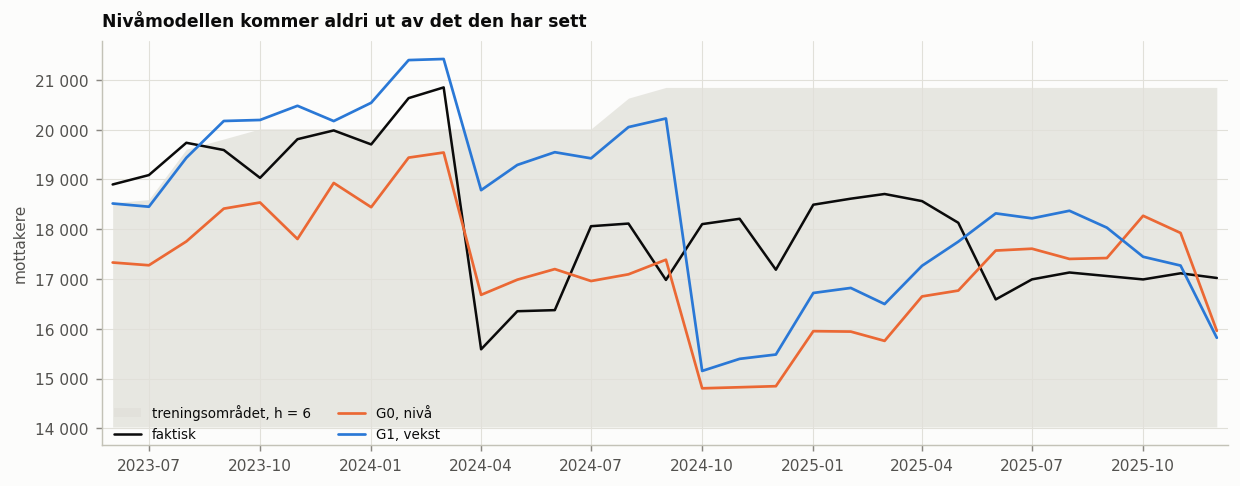

In [9]:
d = R[R.h == 6].sort_values("dato")
fig, ax = plt.subplots(figsize=(9.6, 3.8))
ax.fill_between(d.dato, np.exp(d.gulv), np.exp(d.tak), color=RUTE, alpha=0.75,
                lw=0, label="treningsområdet, h = 6")
ax.plot(d.dato, d.sant, color=BLEKK, lw=1.4, label="faktisk")
ax.plot(d.dato, np.exp(d.G0), color=SERIE[1], lw=1.5, label="G0, nivå")
ax.plot(d.dato, np.exp(d.G1), color=SERIE[0], lw=1.5, label="G1, vekst")
ax.yaxis.set_major_formatter(plt.FuncFormatter(tusen))
ax.set_ylabel("mottakere")
ax.set_title("Nivåmodellen kommer aldri ut av det den har sett")
ax.legend(loc="lower left", ncols=2, bbox_to_anchor=(0, -0.02))
ax.margins(x=0.01)
fig.tight_layout(); plt.show()


Det skraverte feltet er intervallet mellom høyeste og laveste treningsmål ved hver
opprinnelse, for seks måneders horisont. Den oransje linjen forlater det aldri — ikke
i denne ruten og ikke i noen av de 372 punktene. Den blå gjør det, tydeligst gjennom
2023 og fram til bruddet. Og den svarte gjør det: i denne ruten fem ganger av 31, i
hele materialet 56 ganger av 372 ligger utfallet over alt modellen har sett.

På de 56 punktene er G0s MASE 1,83 mot 0,74 for den naive modellen. Å ikke gjøre noe
er der to og en halv gang bedre enn å boostet seg fram til et svar. Innenfor
treningsområdet er forholdet snudd: 0,90 mot 1,05.

**P1 holdt**, og den holdt eksakt: null av 372. **P2 holdt også** — vekstvarianten går
utenfor treningsområdet 44 ganger, og i 22 av de 56 tilfellene der utfallet ligger
over taket, kommer den seg over taket selv. Ankeret legges til
etter at modellen har talt, og da er nivået ikke lenger begrenset av hva som er sett.

Det generelle: grensen er ikke en svakhet ved algoritmen, men ved parametriseringen.
Samme modell, samme trekk, samme data — bare et annet mål — og taket forsvinner.


## 7. Resultatene mot stigen

Nå tallene. Kolonnen `kilde` skiller de to radene som er kontrollert i Python fra de
seks som er avskrift fra arbeidsverk 1.


In [10]:
STIGE = pd.DataFrame(
    [["M2 ETS", 0.931, 1565], ["M3 SARIMA", 1.131, 1944], ["M4 RegARIMA + k", 1.063, 1823],
     ["M5 RegARIMA + X", 0.867, 1391], ["M6 RegARIMA + X + k", 0.967, 1525],
     ["M7 M6 + paalagt bidrag", 0.838, 1322]],
    columns=["modell", "MASE", "RMSE"])
STIGE["kilde"] = "arbeidsverk 1"

NAVN = {"M0": "M0 naiv", "M1": "M1 sesongnaiv", "G0": "G0 boosting, nivaa",
        "G1": "G1 boosting, vekst", "G2": "G2 boosting, vekst, global",
        "N1": "N1 lineaer basis + boostet rest",
        "G1u": "G1u som G1, uten regelverk", "G2u": "G2u som G2, uten regelverk"}
her = pd.DataFrame([dict(modell=NAVN[m], **maal(R, m)) for m in MODELLER])
her["kilde"] = ["kontrollert her"]*2 + ["denne notebooken"]*6

tabell = pd.concat([her, STIGE], ignore_index=True).sort_values("MASE")
tabell["MASE"] = tabell.MASE.round(3); tabell["RMSE"] = tabell.RMSE.round(0)
tabell.set_index("modell", inplace=True); tabell.index.name = None
tabell


,MASE,RMSE,kilde
"G2 boosting, vekst, global",0.815,1408.0,denne notebooken
M7 M6 + paalagt bidrag,0.838,1322.0,arbeidsverk 1
M5 RegARIMA + X,0.867,1391.0,arbeidsverk 1
"G1 boosting, vekst",0.905,1488.0,denne notebooken
M2 ETS,0.931,1565.0,arbeidsverk 1
M6 RegARIMA + X + k,0.967,1525.0,arbeidsverk 1
M0 naiv,1.003,1698.0,kontrollert her
"G0 boosting, nivaa",1.043,1668.0,denne notebooken
M4 RegARIMA + k,1.063,1823.0,arbeidsverk 1
N1 lineaer basis + boostet rest,1.066,1738.0,denne notebooken


Fire ting i tabellen, i den rekkefølgen de bør leses.

**G2 har lavest MASE av alt, også lavere enn M7.** M7 er den modellen i arbeidsverk 1
som får pålagt effekten av en regelendring med en koeffisient estimert på hele
utvalget — altså perfekt informasjon, som rapporten selv kaller en øvre grense. At en
modell uten den informasjonen havner under, er verdt å merke seg.

**Men RMSE forteller noe annet.** G2 har 1 408 mot M7s 1 322 og M5s 1 391. G2 er
altså bedre på den typiske feilen og dårligere på de store. MASE er et snitt av
absoluttfeil, RMSE straffer haler. Rangeringen avhenger av hvilken av dem man bryr
seg om, og det avhenger igjen av hva prognosen skal brukes til. En etat som
dimensjonerer kapasitet, bryr seg mest om halen.

**Den mest sammenliknbare raden er M5, ikke M7.** M5 er RegARIMA med den samme
intervensjonsmatrisen som G2 får, uten kalenderleddet. MASE 0,867 mot 0,815, RMSE
1 391 mot 1 408. Det er i praksis uavgjort mellom to modellklasser som får samme
informasjon.

**N1 gjorde det den skulle.** Den boostede residualvarianten ligger på 1,066, altså
dårligere enn å ikke gjøre noe, og klart dårligere enn den samme modellen brukt
direkte på vekst (0,905). **P3 holdt.**


In [11]:
def dm_harvey(R, a, b, h, noestet=False):
    x = R[R.h == h]
    e1 = (x.sant - np.exp(x[a])).values
    e2 = (x.sant - np.exp(x[b])).values
    n = len(e1)
    d = e1**2 - (e2**2 - (e1-e2)**2) if noestet else e1**2 - e2**2
    L, dc = h - 1, None
    dc = d - d.mean()
    gamma = np.array([(dc[:n-k]*dc[k:]).sum()/n for k in range(L+1)])
    v = (gamma[0] + 2*gamma[1:].sum())/n
    if not np.isfinite(v) or v <= 0:
        return np.nan
    return (d.mean()/np.sqrt(v)) * np.sqrt((n + 1 - 2*h + h*(h-1)/n)/n)

PAR = [("M0", "G1"), ("M0", "G2"), ("G1", "G2"), ("M0", "N1"), ("G0", "G1")]
dm = pd.DataFrame({f"{a} mot {b}": [dm_harvey(R, a, b, h) for h in [1, 3, 6, 12]]
                   for a, b in PAR}, index=pd.Index([1, 3, 6, 12], name="h")).round(2)
print("Positiv verdi favoriserer modellen som staar sist. Ensidig kritisk verdi: 1,64.\n")
dm.T


Positiv verdi favoriserer modellen som staar sist. Ensidig kritisk verdi: 1,64.



h,1,3,6,12
M0 mot G1,0.89,0.79,0.07,0.05
M0 mot G2,1.01,1.40,0.76,0.34
G1 mot G2,1.17,2.25,3.51,1.59
M0 mot N1,0.25,0.08,-0.27,0.07
G0 mot G1,0.32,0.02,-0.09,0.02


Her strammes bildet inn. Ingen av de trebaserte modellene skiller seg fra den naive
med en teststatistikk over 1,64 på noen av de fire horisontene. Forbedringen i MASE
fra 1,003 til 0,815 er reell i den forstand at den er målt på 372 punkter, men den er
ikke større enn det 31 opprinnelser kan skille fra tilfeldighet.

Ett par gjør det. **G1 mot G2** — altså den lokale mot den globale — gir 2,25 ved
h = 3 og 3,51 ved h = 6. Det er den eneste sammenlikningen i tabellen som passerer,
og den handler ikke om maskinlæring mot referanse, men om hvordan den samme modellen
trenes.


## 8. P4 falt: panelet hjalp

Forhåndsregistreringen sa at kryssæring over bydelene ville gi lite, fordi effektiv
dimensjon i panelet er 1,2 av 15. Den påstanden holdt ikke. G2 slår G1 med 0,815 mot
0,905, og forskjellen er den eneste i notebooken som er statistisk skillbar.

Det er verdt å være presis på hvorfor begrunnelsen sviktet, for feilen ligger i
slutningen og ikke i målingen. Effektiv dimensjon 1,2 sier at bydelene bærer **én**
felles bevegelse — at de ikke inneholder femten uavhengige signaler om Oslos framtid.
Det er riktig, og det ble bekreftet i notebook 01. Men en trebasert modell trent på 60
rader lider ikke av for lite informasjon i første rekke; den lider av for få
**eksempler**. Femten bydeler som gjentar den samme sammenhengen, gir modellen femten
ganger så mange observasjoner av den, og reduserer variansen i det den lærer.

Kryssæringen virker altså ikke som ny informasjon, men som regularisering. Skillet er
ikke akademisk: det forutsier at gevinsten forsvinner hvis modellen får nok data fra
Oslo alene, og at den ikke ville vokse av å legge til enda flere kollineære serier.
Ingen av delene er testet her.

Cellen under viser hvorfor dette ikke er hele historien.


In [12]:
abl = pd.DataFrame({
    "med regelverk":  [maal(R, m)["MASE"] for m in ["G1", "G2"]],
    "uten regelverk": [maal(R, m)["MASE"] for m in ["G1u", "G2u"]],
}, index=["lokal (G1)", "global (G2)"]).round(3)
abl["endring"] = (abl["uten regelverk"] - abl["med regelverk"]).round(3)
abl.index.name = None
print(f"Den naive modellen ligger paa {maal(R, 'M0')['MASE']:.3f}.\n")
abl


Den naive modellen ligger paa 1.003.



,med regelverk,uten regelverk,endring
lokal (G1),0.905,1.188,0.283
global (G2),0.815,1.249,0.434


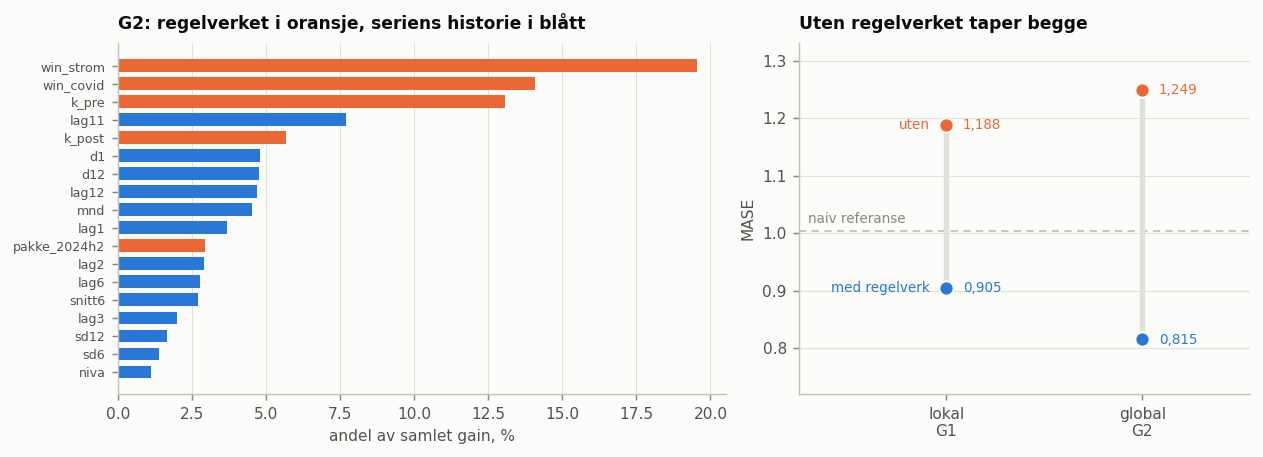

In [13]:
V = pd.concat(VIKTIGHET, axis=1).mean(axis=1).sort_values(ascending=False)
V = 100 * V / V.sum()
gruppe = pd.Series({
    "regelverksregressorer": V[[r for r in REG if r in V.index]].sum(),
    "seriens egen historie": V[[i for i in V.index if i not in REG and i != "mnd"]].sum(),
    "månedsnummer": V.get("mnd", 0.0)}).round(1)

fig, akser = plt.subplots(1, 2, figsize=(9.6, 3.4), layout="constrained",
                          gridspec_kw={"width_ratios": [1.35, 1]})
ax = akser[0]
y = np.arange(len(V))[::-1]
ax.barh(y, V.values, color=[SERIE[1] if i in REG else SERIE[0] for i in V.index],
        height=0.7)
ax.set_yticks(y, V.index, fontsize=7)
ax.set_xlabel("andel av samlet gain, %")
ax.set_title("G2: regelverket i oransje, seriens historie i blått")
ax.grid(axis="y", visible=False)

ax = akser[1]
xp = [0, 1]
for i, (a_, b_) in enumerate(zip(abl["med regelverk"], abl["uten regelverk"])):
    ax.plot([i, i], [a_, b_], color=RUTE, lw=3.0, solid_capstyle="round", zorder=2)
    ax.plot(i, a_, "o", ms=8, color=SERIE[0], zorder=4,
            markeredgecolor="#fcfcfb", markeredgewidth=1.2)
    ax.plot(i, b_, "o", ms=8, color=SERIE[1], zorder=4,
            markeredgecolor="#fcfcfb", markeredgewidth=1.2)
    ax.annotate(f"{a_:.3f}".replace(".", ","), xy=(i, a_), xytext=(9, 0),
                textcoords="offset points", ha="left", va="center",
                fontsize=7.5, color=SERIE[0])
    ax.annotate(f"{b_:.3f}".replace(".", ","), xy=(i, b_), xytext=(9, 0),
                textcoords="offset points", ha="left", va="center",
                fontsize=7.5, color=SERIE[1])
NAIV = maal(R, "M0")["MASE"]
ax.axhline(NAIV, color=BASIS, lw=1.0, ls=(0, (4, 3)), zorder=1)
ax.annotate("naiv referanse", xy=(0.02, NAIV), xycoords=("axes fraction", "data"),
            xytext=(0, 3), textcoords="offset points", ha="left", va="bottom",
            fontsize=7.5, color=DEMPET)
ax.annotate("med regelverk", xy=(0, abl["med regelverk"].iloc[0]), xytext=(-9, 0),
            textcoords="offset points", ha="right", va="center",
            fontsize=7.5, color=SERIE[0])
ax.annotate("uten", xy=(0, abl["uten regelverk"].iloc[0]), xytext=(-9, 0),
            textcoords="offset points", ha="right", va="center",
            fontsize=7.5, color=SERIE[1])
ax.set_xticks(xp, ["lokal\nG1", "global\nG2"])
ax.set_xlim(-0.75, 1.55)
ax.set_ylabel("MASE"); ax.set_ylim(0.72, 1.33)
ax.grid(axis="x", visible=False)
ax.set_title("Uten regelverket taper begge")
plt.show()


Venstre rute fordeler modellens forklaringskraft. De fem regelverksregressorene står
for over halvparten av samlet gain, og `win_strom`, `win_covid` og `k_pre` er de tre
øverste. Modellen bruker altså i hovedsak det samme som arbeidsverk 1s M5 og M6
bruker: daterte regelendringer.

Høyre rute gjør det om fra indikasjon til måling. Uten regelverksregressorene stiger
MASE fra 0,905 til 1,188 for den lokale varianten og fra 0,815 til 1,249 for den
globale. Begge havner over den naive referansen på 1,003. **Hele fordelen over det å
ikke gjøre noe kommer fra regelverket.**

Og kryssæringen snur fortegn. Med regelverket hjelper panelet (0,905 → 0,815); uten
det skader det (1,188 → 1,249). Det er konsistent med tolkningen over: det bydelene
har til felles er hvordan regelendringer slår gjennom, og uten regressorene som
daterer endringene, er de øvrige seriene mest støy fra andre bydelers særtrekk.

Konklusjonen er ubehagelig for en søknad som skal vise fram maskinlæring, og den skal
stå likevel: **det er domenekunnskapen som bærer prognosen her, ikke algoritmen.**
Modellklassen avgjør hvor fleksibelt den informasjonen brukes, og det er en reell
forskjell — men den er annenordens.


## 9. Oppgjør med forhåndsregistreringen


In [14]:
oppgjor = pd.DataFrame([
    ["P1", "Nivaamodellen kan ikke ekstrapolere",
     f"{int(R.utenfor_G0.sum())} av {len(R)} prognoser utenfor treningsomraadet", "holdt"],
    ["P2", "Vekstparametrisering fjerner taket",
     f"{int(R.utenfor_G1.sum())} av {len(R)} utenfor", "holdt"],
    ["P3", "Residual-ML slaar ikke modellen alene",
     f"N1 {maal(R,'N1')['MASE']:.3f} mot G1 {maal(R,'G1')['MASE']:.3f}", "holdt"],
    ["P4", "Kryssaering over bydelene gir lite",
     f"G2 {maal(R,'G2')['MASE']:.3f} mot G1 {maal(R,'G1')['MASE']:.3f}, "
     f"DM 3,51 ved h = 6", "FALT"],
], columns=["", "paastand", "maalt", "utfall"]).set_index("")
oppgjor


,paastand,maalt,utfall
,,,
P1,Nivaamodellen kan ikke ekstrapolere,0 av 372 prognoser utenfor treningsomraadet,holdt
P2,Vekstparametrisering fjerner taket,44 av 372 utenfor,holdt
P3,Residual-ML slaar ikke modellen alene,N1 1.066 mot G1 0.905,holdt
P4,Kryssaering over bydelene gir lite,"G2 0.815 mot G1 0.905, DM 3,51 ved h = 6",FALT


Tre av fire holdt. Den som falt, falt på en begrunnelse som var riktig målt og feil
brukt: effektiv dimensjon sier noe om hvor mye uavhengig informasjon et panel bærer,
ikke om hvor mange eksempler en modell trenger for å lære en sammenheng med lav
varians. Det er den nyttige lærdommen fra denne notebooken, og den var ikke tilsiktet.


## 10. Hva notebook 04 arver, og hva som står åpent

Notebook 04 tar nevrale nett. Fra denne notebooken følger:

- Trekkmatrisen og `trekk()`, med lekkasjetesten.
- Ablasjonsoppsettet: enhver modell kjøres også uten regelverksregressorene, slik at
  det alltid er målt hvor mye av resultatet som er domenekunnskap.
- Forhåndsregistrering før kjøring, og et oppgjør etterpå.

Fem ting står åpne og skal ikke framstilles som løst:

1. **Ingen hyperparametersøk.** Verdiene er satt på forhånd. Et søk ville krevd
   nestet kryssvalidering innenfor hvert treningsvindu, og resultatene her sier
   ingenting om hva modellen kunne oppnådd med justering.
2. **Ingen intervaller fra modellene.** G-variantene gir punktprognoser, så tabellen
   i avsnitt 7 har bare MASE og RMSE — dekning og intervallskår er ikke oppgitt for
   dem, og stigen kan derfor bare sammenliknes på punktmålene. Det tidsgyldige
   konformale skjemaet fra notebook 02 er veien dit, og hører hjemme i notebook 05
   sammen med avstemmingen.
3. **Én kjøring per variant.** `random_state` er fast, men resultatene er ikke
   gjentatt over flere frø. Spredningen mellom frø er ukjent.
4. **Sammenlikningen mot seks av trinnene er avskrift.** Se kildekolonnen.
5. **Regressorene i målmåneden.** Modellen får vite at det midlertidige regelverket
   avvikles i april 2024 før det skjer, fordi vedtaket forelå. Det er samme
   forutsetning som arbeidsverk 1 gjør, men den er en forutsetning, og en pipeline i
   drift må kunne dokumentere at datoen faktisk var kjent på prognosetidspunktet.


### Kjøremanifest


In [15]:
MANIFEST["protokoll"] = {"opprinnelser": len(OPPRINNELSER), "h_maks": H_MAKS,
                         "punkter": int(len(R)),
                         "treningsrader_min": int(R.n_trening.min()),
                         "treningsrader_maks": int(R.n_trening.max())}
MANIFEST["resultat"] = {m: {"MASE": round(float(maal(R, m)["MASE"]), 3),
                            "RMSE": round(float(maal(R, m)["RMSE"]))} for m in MODELLER}
MANIFEST["forhaandsregistrering"] = {
    "P1_ekstrapolering": f"holdt, {int(R.utenfor_G0.sum())} av {len(R)} utenfor",
    "P2_vekstparametrisering": f"holdt, {int(R.utenfor_G1.sum())} av {len(R)} utenfor",
    "P3_residual_ml": "holdt",
    "P4_kryssaering": "falt"}
MANIFEST["ablasjon"] = {
    "G1_uten_regelverk": round(float(maal(R, "G1u")["MASE"]), 3),
    "G2_uten_regelverk": round(float(maal(R, "G2u")["MASE"]), 3),
    "regelverkets_andel_av_gain_pst": float(gruppe["regelverksregressorer"])}
MANIFEST["kontroller"] = {
    "protokoll_mot_arbeidsverk1": "10 av 10 tall like",
    "lekkasjetest_trekk": f"{len(KILDER)*len(trekk(M, KILDER[0]))} verdier, 0 avvik",
    "harmoni_med_main": MANIFEST_HARMONI,
    "lenke_notebook02": LENKE}
print(json.dumps(MANIFEST, indent=2, ensure_ascii=False))


{
  "commit": "056030c",
  "uttrekk": "2026-08-04",
  "python": "3.11.15",
  "pakker": {
    "numpy": "2.4.4",
    "pandas": "3.0.2",
    "sklearn": "1.8.0",
    "xgboost": "3.2.0",
    "matplotlib": "3.10.9"
  },
  "sjekksum": {
    "husbanken_bostotte_oslo_manedlig.csv": "5e741e0864bd8d666057b627170ebf0b47229ea846f0ed98717cc5bc590600d6"
  },
  "seed": 20260807,
  "lenke_notebook02": "samme uttrekk og samme fil",
  "protokoll": {
    "opprinnelser": 31,
    "h_maks": 12,
    "punkter": 372,
    "treningsrader_min": 48,
    "treningsrader_maks": 89
  },
  "resultat": {
    "M0": {
      "MASE": 1.003,
      "RMSE": 1698
    },
    "M1": {
      "MASE": 1.228,
      "RMSE": 1844
    },
    "G0": {
      "MASE": 1.043,
      "RMSE": 1668
    },
    "G1": {
      "MASE": 0.905,
      "RMSE": 1488
    },
    "G2": {
      "MASE": 0.815,
      "RMSE": 1408
    },
    "N1": {
      "MASE": 1.066,
      "RMSE": 1738
    },
    "G1u": {
      "MASE": 1.188,
      "RMSE": 1985
    },
    "G2u":